# Load the AIS data and visualize your first ship trajectory

## Import relevant libraries

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

## Use pandas to load the AIS data
### Understanding the AIS dataset

The AIS (Automatic Identification System) dataset records the real-time navigation status of ships.  
Each row in the table represents a single AIS message transmitted by a vessel at a specific timestamp.  
Here’s what each column means:

- **IMO** – The International Maritime Organization (IMO) number, a unique identifier assigned to each ship.  
- **Date/Time** – The exact UTC time when the AIS message was recorded.  
- **Lat / Lng** – The latitude and longitude coordinates of the vessel’s position.  
- **Heading** – The direction the ship’s bow is pointing, measured in degrees from true north (0–360°).  
- **SOG (Speed Over Ground)** – The ship’s actual speed relative to the ground, measured in knots.  
- **COG (Course Over Ground)** – The ship’s actual course or path over the Earth’s surface, measured in degrees.  
- **Draught** – The vertical distance between the waterline and the bottom of the hull (keel), indicating how deeply the vessel sits in the water.  
- **Navigation status** – The operational condition of the ship (e.g., *Under Way*, *At Anchor*, *Moored*).

Together, these parameters describe the vessel’s movement and status at sea, enabling us to reconstruct its trajectory and analyze its navigation behavior.

In [3]:
df = pd.read_csv('../data/AIS_data.csv')

In [4]:
df.head()

,IMO,Date/Time,Lat,Lng,Heading,SOG,COG,draught,Navigation status
0,9595527,2021-04-24 21:32:00,34.247222,129.783611,230.0,21.4,230.3,12.0,Under Way
1,9595527,2021-04-24 21:35:00,34.235556,129.767500,230.0,21.2,228.6,12.0,Under Way
2,9595527,2021-04-24 21:38:00,34.224167,129.751111,230.0,21.1,229.3,12.0,Under Way
3,9595527,2021-04-24 21:41:00,34.212778,129.735000,230.0,21.1,229.4,12.0,Under Way
4,9595527,2021-04-24 21:44:00,34.201667,129.719444,230.0,21.1,229.7,12.0,Under Way


## Now we can filter a trajectory

### Filtering and visualizing a ship trajectory

In this step, we focus on **one specific ship (IMO 9595527)** and visualize its movement during a selected time window.

Here’s what the code does:

1. **Filter by IMO number**  
   We extract only the records that belong to the target ship, identified by its unique IMO number.

2. **Convert timestamps**  
   The `Date/Time` column is converted to Python’s datetime format, allowing accurate date filtering.

3. **Select data for specific dates**  
   We use a logical mask to include only the records from **April 24 and April 25, 2021**.  
   This isolates a short segment of the ship’s voyage.

4. **Plot latitude vs longitude**  
   The trajectory is visualized using `matplotlib`, where longitude is on the x-axis and latitude is on the y-axis.  
   Each blue dot represents an AIS position report sent by the vessel.

5. **Enhance readability**  
   Titles, axis labels, and grid lines are added to make the chart easier to interpret.

The resulting figure shows the **path of the ship over time**, allowing us to observe its navigation pattern across the selected period.


In [4]:
# 1️⃣  Filter records for the specific ship (IMO = 9595527)
df_ship = df[df['IMO'] == 9595527].copy()
df_ship

,IMO,Date/Time,Lat,Lng,Heading,SOG,COG,draught,Navigation status
0,9595527,2021-04-24 21:32:00,34.247222,129.783611,230.0,21.4,230.3,12.0,Under Way
1,9595527,2021-04-24 21:35:00,34.235556,129.767500,230.0,21.2,228.6,12.0,Under Way
2,9595527,2021-04-24 21:38:00,34.224167,129.751111,230.0,21.1,229.3,12.0,Under Way
3,9595527,2021-04-24 21:41:00,34.212778,129.735000,230.0,21.1,229.4,12.0,Under Way
4,9595527,2021-04-24 21:44:00,34.201667,129.719444,230.0,21.1,229.7,12.0,Under Way
...,...,...,...,...,...,...,...,...,...
474,9595527,2021-10-05 00:15:00,34.257500,129.721944,47.0,23.1,46.4,14.1,Under Way
475,9595527,2021-10-05 00:18:00,34.268611,129.737222,53.0,23.1,52.6,14.1,Under Way
476,9595527,2021-10-05 00:20:00,34.279167,129.754167,52.0,22.9,52.0,14.1,Under Way
477,9595527,2021-10-05 00:21:00,34.279444,129.754444,52.0,22.9,52.0,14.1,Under Way


In [5]:
# 2️⃣  Convert "Date/Time" column to datetime format
df_ship['Date/Time'] = pd.to_datetime(df_ship['Date/Time'])

In [6]:
# 3️⃣  Filter for the two target dates: 2021-04-24 and 2021-04-25
mask = (df_ship['Date/Time'].dt.date >= pd.to_datetime('2021-04-24').date()) & \
       (df_ship['Date/Time'].dt.date <= pd.to_datetime('2021-04-25').date())
df_filtered = df_ship.loc[mask]
df_filtered

,IMO,Date/Time,Lat,Lng,Heading,SOG,COG,draught,Navigation status
0,9595527,2021-04-24 21:32:00,34.247222,129.783611,230.0,21.4,230.3,12.0,Under Way
1,9595527,2021-04-24 21:35:00,34.235556,129.767500,230.0,21.2,228.6,12.0,Under Way
2,9595527,2021-04-24 21:38:00,34.224167,129.751111,230.0,21.1,229.3,12.0,Under Way
3,9595527,2021-04-24 21:41:00,34.212778,129.735000,230.0,21.1,229.4,12.0,Under Way
4,9595527,2021-04-24 21:44:00,34.201667,129.719444,230.0,21.1,229.7,12.0,Under Way
...,...,...,...,...,...,...,...,...,...
108,9595527,2021-04-25 03:38:00,32.680556,127.989167,223.0,21.7,224.4,12.0,Under Way
109,9595527,2021-04-25 03:41:00,32.668333,127.975278,223.0,21.7,224.1,12.0,Under Way
110,9595527,2021-04-25 03:44:00,32.652500,127.958056,219.0,21.5,219.5,12.0,Under Way
111,9595527,2021-04-25 03:48:00,32.633889,127.940000,219.0,21.6,219.6,12.0,Under Way


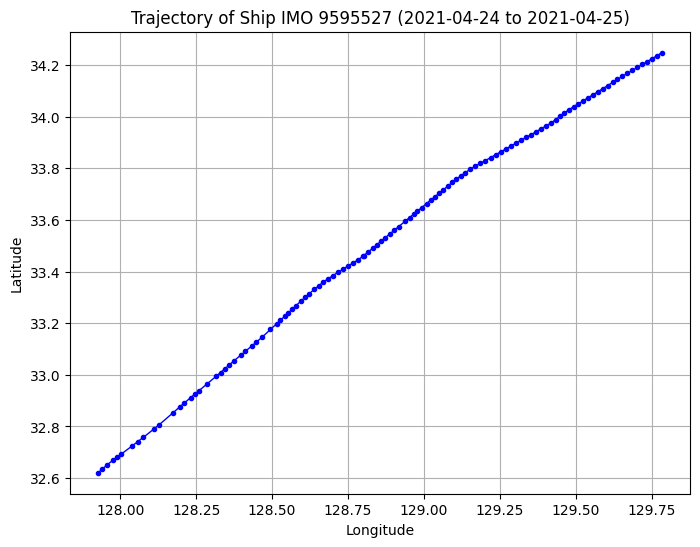

In [7]:
# 4️⃣  Plot the ship trajectory (Lat vs Lng)
plt.figure(figsize=(8, 6))
plt.plot(df_filtered['Lng'], df_filtered['Lat'], marker='o', markersize=3, linewidth=1, color='blue')

# 5️⃣  Add title and labels
plt.title('Trajectory of Ship IMO 9595527 (2021-04-24 to 2021-04-25)', fontsize=12)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True)
plt.show()
